# Pandas Assignment — Temperature Sensor Analysis

**Instructions:**
- Read each question **carefully before running any code cell**
- Write your answers in the `[YOUR ANSWER]` cells — these require written explanations, not just code
- Some code cells are intentionally left blank: you need to write the code yourself
- Focus on *why* things work, not just *what* to type

**Estimated time:** ~70 minutes

---
## Part 1 — Get to Know the Dataset (15 min)

You have been given a new dataset: `assignment_data.csv`.  
It contains measurements recorded by a temperature sensor in a lab environment.

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('assignment_data.csv')
df

,time_s,temperature_C
0,0.00,26.226
1,0.01,20.835
2,0.02,22.082
3,0.03,23.019
4,0.04,20.028
...,...,...
1995,19.95,25.491
1996,19.96,26.951
1997,19.97,22.885
1998,19.98,21.358


**Q1.1** — Before using any pandas function, just from looking at the column names and the first few rows:
- What does each column represent?
- What unit does each column likely use?
- How often is the sensor sampling, in Hz? *(Hint: look at the time step between consecutive rows)*

> **[YOUR ANSWER 1.1]**
- Column 1 represents the time in seconds. Column 2 represents a temperature recorded in Celsius. 
- The sensor samples at least every 0.01 seconds = 100 Hz. 

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time_s         2000 non-null   float64
 1   temperature_C  1982 non-null   float64
dtypes: float64(2)
memory usage: 31.4 KB


In [55]:
df.describe()

,time_s,temperature_C
count,2000.000000,1982.000000
mean,9.995000,22.027869
std,5.774946,3.445123
min,0.000000,13.861000
25%,4.997500,20.246250
50%,9.995000,21.912500
75%,14.992500,23.610500
max,19.990000,73.082000


**Q1.2** — Look at the output of `df.info()` and `df.describe()` together:
- How many missing values are there in `temperature_C`? *(Hint: compare Non-Null Count to the total number of rows)*
- What is the maximum temperature recorded? Is that a realistic lab temperature? What do you suspect about those readings?

> **[YOUR ANSWER 1.2]**
- 18 missing values are in `temperature_C`. The total row count minus the count of the temperature row equals 18 (`2000-1982=18`).
- The maximum temperature recorded was 73.082 Celsius. 
- This could be a realistic temperature of an IC or something heating up but the min of 13.86 is wierd. Seems like more likely an outlier because the mean is around 22.0 degrees and the std is 3.445.

In [56]:
df.isna().sum()

time_s            0
temperature_C    18
dtype: int64

**Q1.3** — Write a **single line of code** below to display only the rows where `temperature_C` is greater than 50.  
How many rows are there?

In [57]:
# YOUR CODE HERE
df[df['temperature_C'] > 50]

,time_s,temperature_C
261,2.61,69.098
717,7.17,64.090
728,7.28,73.082
743,7.43,70.984
1322,13.22,70.786


**Q1.4** — Based on what you found above:
- What percentage of the 2000 rows do these high-temperature readings represent?
- Do you think they are real measurements or sensor errors? Justify your reasoning.

> **[YOUR ANSWER 1.4]**
- The high-temperature reading represent 0.25% of the 2000 rows in the dataframe.
- The fact none of the high temperatures happened near the same time is an indicator these might be sensor errors. Instead of seeing any sort of natural rise towards the outliers we see a quick spikes, seconds apart. This would make me believe this aren't real measurements but simply sensor errors. 

---
## Part 2 — Handling Missing Data (15 min)

**Q2.1** — **Before writing any code**, think about this scenario:  
If you use `df.fillna(0)` to replace the missing temperature values with 0:
- What temperature does 0 represent in Celsius?
- Is that a realistic lab temperature?
- What problem would this introduce when you later compute the mean?

> **[YOUR ANSWER 2.1]**
- 0 deg. Celsius is 32 deg. Fahrenheit.
- No this is not a realistic lab temperature because the mean is around 22.0, and 0 degrees Celsius is freezing.
- The mean for time_s is only changes slightly: Dropped (9.985010) vs. Original (9.995000). The mean for the temperature does not change.

In [58]:
# Strategy A: drop rows with missing values
df_dropped = df.dropna()
print("Rows remaining after dropna():", len(df_dropped))
print("Rows lost:", len(df) - len(df_dropped))
df_dropped.mean()

Rows remaining after dropna(): 1982
Rows lost: 18


time_s            9.985010
temperature_C    22.027869
dtype: float64

In [59]:
# Strategy B: fill missing values with the column mean
mean_temp = df['temperature_C'].mean()
df_filled = df.fillna(mean_temp)
print("Mean used to fill:", round(mean_temp, 3))
print("Missing values remaining:", df_filled['temperature_C'].isna().sum())
df_filled.mean()

Mean used to fill: 22.028
Missing values remaining: 0


time_s            9.995000
temperature_C    22.027869
dtype: float64

**Q2.2** — Compare the two strategies:
- Strategy A loses rows. Is losing roughly 1% of the data acceptable here? What could you lose along with it?
- Strategy B keeps all rows but replaces NaN with an estimate. Does that introduce any distortion into the data?
- Which strategy would you choose for this dataset, and why?

> **[YOUR ANSWER 2.2]**
- Strategy A loses ~1% of the data and could drop real events or spikes.  
- Strategy B keeps all rows and only slightly distorts the mean, so I would choose B.

In [60]:
# Apply your chosen strategy — change this if you prefer dropna()
df_clean = df.fillna(df['temperature_C'].mean())
print("Working dataset has", len(df_clean), "rows")

Working dataset has 2000 rows


---
## Part 3 — Visualise and Interpret (15 min)

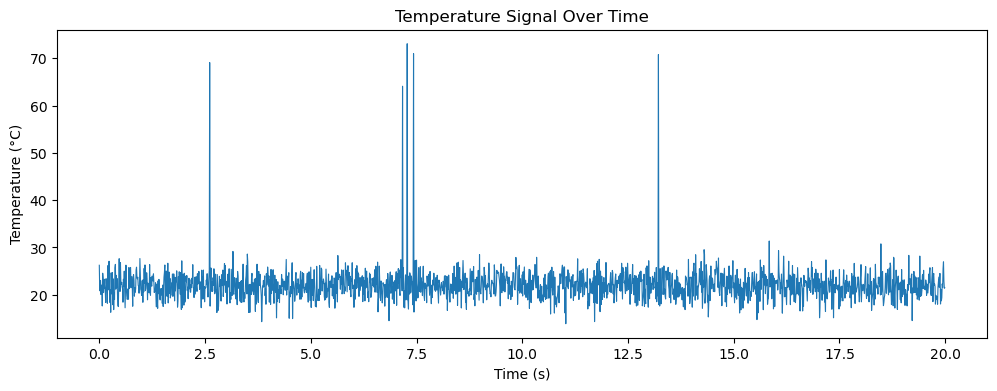

In [61]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Signal Over Time')
plt.show()

**Q3.1** — Describe what you see in the plot:
- Is the signal noisy or smooth?
- Are there any obvious spikes or sudden jumps?
- Does the signal appear to increase, decrease, or stay roughly constant over time?

> **[YOUR ANSWER 3.1]**
- The signal is a noisy.
- There are a few obvious spikes/jumps.
- Overall it stays roughly constant over time.

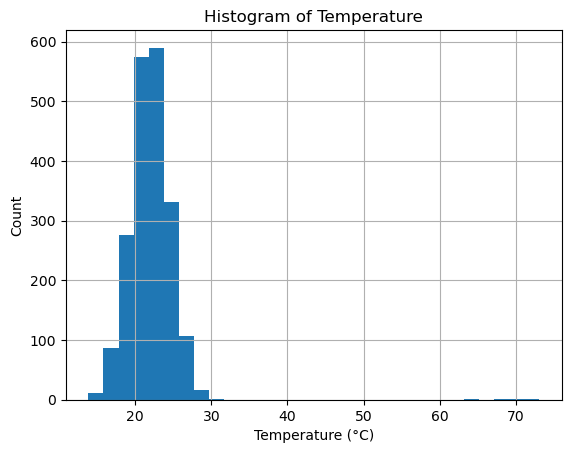

In [62]:
df_clean['temperature_C'].hist(bins=30)
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Histogram of Temperature')
plt.show()

**Q3.2** — Look at the histogram:
- Is the main distribution roughly symmetric, or skewed?
- Do you see an isolated cluster of bars far to the right? What do those correspond to?
- If you removed those outlier readings, how would the histogram change?

> **[YOUR ANSWER 3.2]**
- The main distribution looks roughly symmetric but slightly right skewed.
- The short bars all the way on the right are the high-temp outliers.
- Removing them would tighten the histogram around the center of the graph.

**Q3.3** — **Before running the cell below**, make a prediction:  
Given that the dataset contains a few very high temperature outliers, do you expect the mean to be **higher than**, **lower than**, or **about the same as** the median?  
Write your prediction and your reasoning first, then run the code to check.

> **[YOUR PREDICTION 3.3]**
- The mean should be higher than the median because the outliers pull it up.

In [63]:
# YOUR CODE HERE
# Compute and print the mean and median of temperature_C

display(df_clean['temperature_C'].mean())
display(df_clean['temperature_C'].median())

np.float64(22.02786881937437)

np.float64(21.958)

**Q3.4** — Was your prediction correct?  
In one sentence, explain *why* the mean and median behave differently when outliers are present.

> **[YOUR ANSWER 3.4]**
- Yes, because the mean is increased by outliers while the median mostly ignores them.

---
## Part 4 — Smoothing the Signal (15 min)

A rolling average smooths a noisy signal by replacing each value with the average of the surrounding samples.  
You control how much smoothing by choosing the **window size** (number of samples used per average).

**Q4.1** — **Before running any code**, use the sampling rate to reason about window sizes:  
The sensor samples at 100 Hz (100 samples per second).
- What time duration (in seconds) does a window of 10 samples represent?
- What time duration does a window of 200 samples represent?

> **[YOUR ANSWER 4.1]**
- 10 samples = 0.10 secs. 
- 200 samples = 2.0 secs.

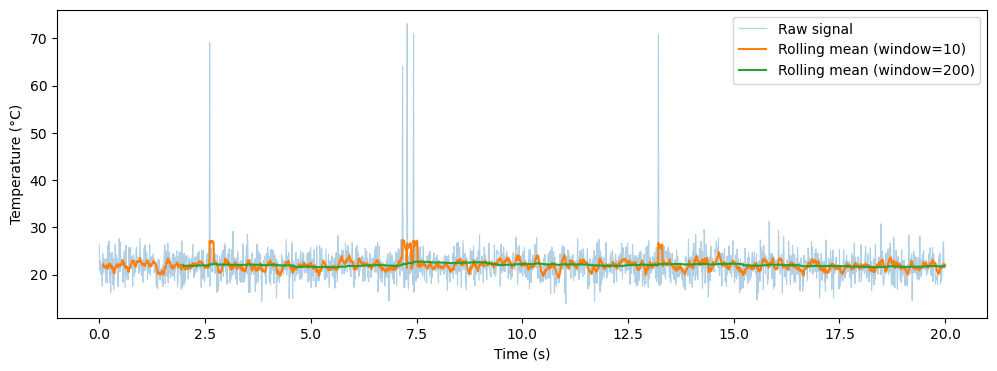

In [64]:
df_clean['rolling_10'] = df_clean['temperature_C'].rolling(window=10).mean()
df_clean['rolling_200'] = df_clean['temperature_C'].rolling(window=200).mean()

plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.35, linewidth=0.8, label='Raw signal')
plt.plot(df_clean['time_s'], df_clean['rolling_10'], linewidth=1.5, label='Rolling mean (window=10)')
plt.plot(df_clean['time_s'], df_clean['rolling_200'], linewidth=1.5, label='Rolling mean (window=200)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

**Q4.2** — Compare the two smoothed signals in the plot:
- Which one tracks the raw signal more closely?
- Which one produces the smoother result?
- At the very beginning of the plot, why does `rolling_200` start later than `rolling_10`?

> **[YOUR ANSWER 4.2]**
- `rolling_10` tracks more closely to the raw signal, we can see the noise and parts of the spikes are preserved.
- `rolling_200` produces a smoother result.
- `rolling_200` starts after `rolling_10` because it needs at least 200 samples before it can compute its first mean.

In [65]:
print("Std of raw signal:    ", round(df_clean['temperature_C'].std(), 4))
print("Std of rolling_10:    ", round(df_clean['rolling_10'].std(), 4))
print("Std of rolling_200:   ", round(df_clean['rolling_200'].std(), 4))

Std of raw signal:     3.4296
Std of rolling_10:     1.0539
Std of rolling_200:    0.2726


**Q4.3** — The standard deviation decreases as the window gets larger.  
Imagine you are building an alarm system that must detect a **sudden large temperature spike** within 0.5 seconds of it happening.  
- Would you use a small or large rolling window? Why?  
- What do you *trade away* by using a larger window?

> **[YOUR ANSWER 4.3]**
- Use a small window so spikes show up fast.
- A larger window trades off quick response and detail (it smears spikes).

---
## Part 5 — Outlier Investigation (10 min)

**Q5.1** — Write code below to:
1. Count how many rows have `temperature_C > 50`
2. Compute what percentage of the total dataset that represents (round to 2 decimal places)

Print both values with clear labels.

In [66]:
# YOUR CODE HERE
count_outliers = (df_clean['temperature_C'] > 50).sum()
percent_outliers = round((count_outliers / len(df_clean)) * 100, 2)

print("Outliers count:", count_outliers)
print("Outliers percent:", percent_outliers, "%")

Outliers count: 5
Outliers percent: 0.25 %


In [67]:
# Mean and median WITH outliers
mean_with = df_clean['temperature_C'].mean()
median_with = df_clean['temperature_C'].median()

# Mean and median WITHOUT outliers
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_without = df_no_outliers['temperature_C'].mean()
median_without = df_no_outliers['temperature_C'].median()

print(f"Mean     WITH outliers: {mean_with:.3f}")
print(f"Mean  WITHOUT outliers: {mean_without:.3f}")
print()
print(f"Median   WITH outliers: {median_with:.3f}")
print(f"Median WITHOUT outliers: {median_without:.3f}")

Mean     WITH outliers: 22.028
Mean  WITHOUT outliers: 21.909

Median   WITH outliers: 21.958
Median WITHOUT outliers: 21.952


**Q5.2** — Look at the numbers above:
- Which statistic changed more when outliers were removed — the mean or the median?
- In one sentence, explain *why* the median is more resistant to outliers than the mean.

> **[YOUR ANSWER 5.2]**
- The mean changes more than the median.
- The median is based on the middle value, so big outliers do effect it.

**Q5.3** — Imagine you are a lab technician reviewing this data.  
Give **one reason why you might remove** the outliers and **one reason why you might keep** them.

> **[YOUR ANSWER 5.3]**
- Remove: they are likely sensor errors that skew averages.
- Keep: they could be real events (like a sudden heat spike) that matter.


---
## Bonus — Putting It All Together *(optional)*

Using everything you have learned, create a **single, well-labelled plot** that shows:
- The raw signal (with low opacity)
- The smoothed signal using the window size you think is most appropriate
- Two horizontal lines: one for the mean and one for the median of the clean signal *(without outliers)*

Add a title, axis labels, and a legend. No written answer required — make it clear and informative.

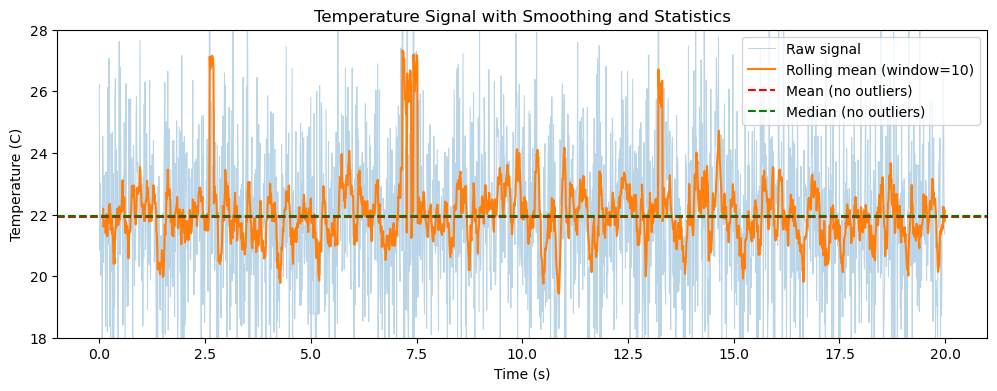

In [68]:
# YOUR CODE HERE

# Raw signal
plt.figure(figsize=(12, 4))
plt.plot(df_clean['time_s'], df_clean['temperature_C'], alpha=0.3, linewidth=0.75, label='Raw signal')

# Smoothed signal (choose window=10 for faster response)
rolling_window = 10
df_clean['rolling_best'] = df_clean['temperature_C'].rolling(window=rolling_window).mean()
plt.plot(df_clean['time_s'], df_clean['rolling_best'], linewidth=1.5, label='Rolling mean (window=10)')

# Mean and median without outliers
df_no_outliers = df_clean[df_clean['temperature_C'] <= 50]
mean_clean = df_no_outliers['temperature_C'].mean()
median_clean = df_no_outliers['temperature_C'].median()

plt.axhline(mean_clean, color='red', linestyle='--', label='Mean (no outliers)')
plt.axhline(median_clean, color='green', linestyle='--', label='Median (no outliers)')

plt.title('Temperature Signal with Smoothing and Statistics')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (C)')
plt.ylim(18, 28)
plt.legend()
plt.show()